In [ ]:
import pandas as pd
import yfinance as yf

#Definiremos la empresa e importamos los datos, al final lo guardamos en un cvs
empresa = 'ACTINVRB.MX'
datos = yf.download(empresa, start='2010-01-01', end='2024-05-22')
datos.to_csv('datos.csv')

[*********************100%%**********************]  1 of 1 completed


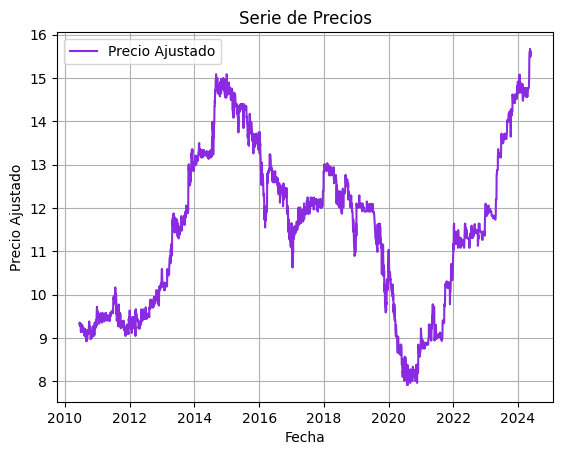

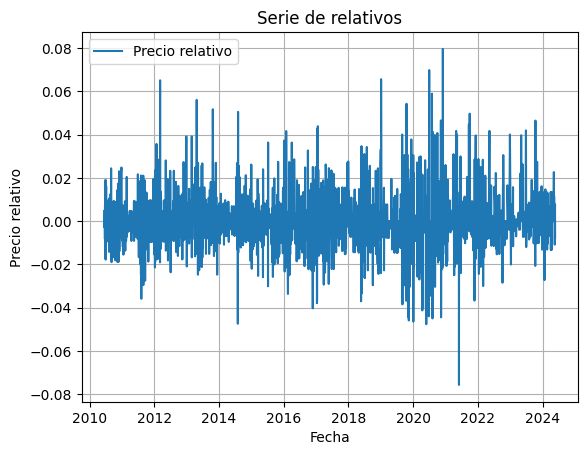

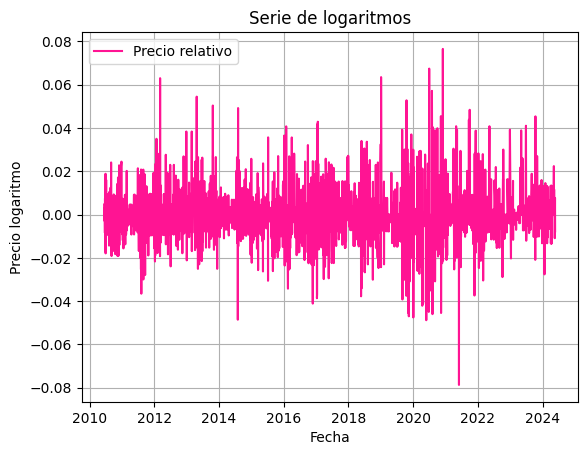

In [ ]:
#preludio y problem 1
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Traemos los datos
datos = pd.read_csv('datos.csv', index_col='Date', parse_dates=True)

# Calculamos X & Y:
datos['relativo'] = (datos['Adj Close'] - datos['Adj Close'].shift(1)) / datos['Adj Close'].shift(1)
datos['log'] = np.log(datos['Adj Close'] / datos['Adj Close'].shift(1))

#Graficamos precio(1), relativo(2) y logaritmo(3):
#1
plt.figure()
plt.plot(datos['Adj Close'], label='Precio Ajustado', color='blueviolet')
plt.title('Serie de Precios')
plt.xlabel('Fecha')
plt.ylabel('Precio Ajustado')
plt.legend()
plt.grid(True)
plt.show()

#2
plt.figure()
plt.plot(datos['relativo'], label='Precio relativo')
plt.title('Serie de relativos')
plt.xlabel('Fecha')
plt.ylabel('Precio relativo')
plt.legend()
plt.grid(True)
plt.show()

#3
plt.figure()
plt.plot(datos['log'], label='Precio relativo', color='deeppink')
plt.title('Serie de logaritmos')
plt.xlabel('Fecha')
plt.ylabel('Precio logaritmo')
plt.legend()
plt.grid(True)
plt.show()


In [ ]:
#problema 2
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm

#Sacamos esperados y varianzas de x
media_x = datos['relativo'].mean()
var_x = datos['relativo'].var()

#Sacamos esperados y varianzas de y
media_y = datos['log'].mean()
var_y = datos['log'].var()

#obtendré las desviaciones estandares
std_x = np.sqrt(var_x)
std_y = np.sqrt(var_y)

print(f'Esperado de X: {media_x}')
print(f'Varianza de X: {var_x}')
print(f'Desviación estandar de X: {std_x}')
print(f'Esperado de Y: {media_y}')
print(f'Varianza de Y: {var_y}')
print(f'Desviación estandar de Y: {std_y}')

Esperado de X: 0.00023067146280567055
Varianza de X: 0.00011590384910076221
Desviación estandar de X: 0.010765864995473527
Esperado de Y: 0.00017298162722063733
Varianza de Y: 0.00011514207766576605
Desviación estandar de Y: 0.010730427655306476


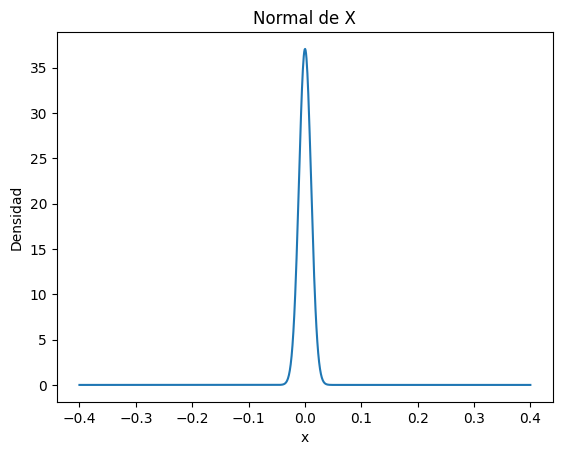

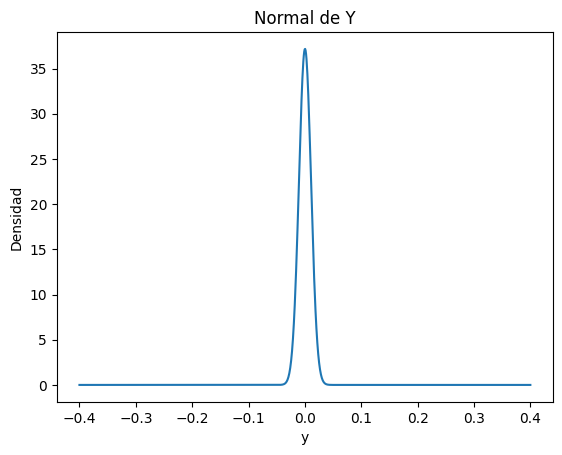

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm

# Genera limites para valores de x para la normal de X & Y
x_v = np.linspace(-0.4,0.4, 1000)
y_v = np.linspace(-0.4,0.4, 1000)

#calculo de normales
dn_x=(1 / (np.sqrt(2 * np.pi) * std_x)) * np.exp(-0.5 * ((x_v - media_x) / std_x) ** 2)
dn_y=(1 / (np.sqrt(2 * np.pi) * std_y)) * np.exp(-0.5 * ((y_v - media_y) / std_y) ** 2)

#mostramos las densidade
plt.figure()
plt.plot(x_v, dn_x, label='distribución normal de x')
plt.xlabel('x')
plt.ylabel('Densidad')
plt.title('Normal de X')
plt.show()

plt.figure()
plt.plot(y_v, dn_y, label='distribución normal de y')
plt.xlabel('y')
plt.ylabel('Densidad')
plt.title('Normal de Y')
plt.show()

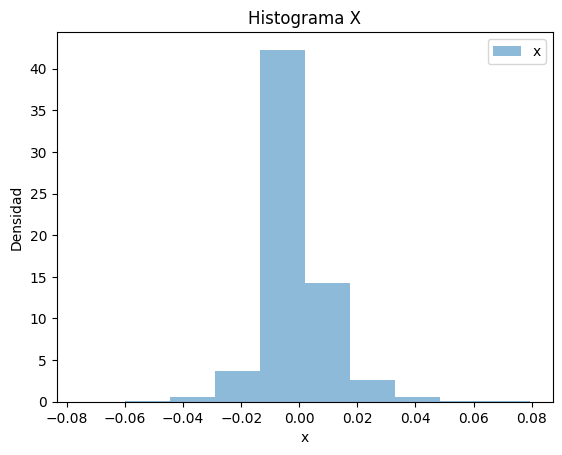

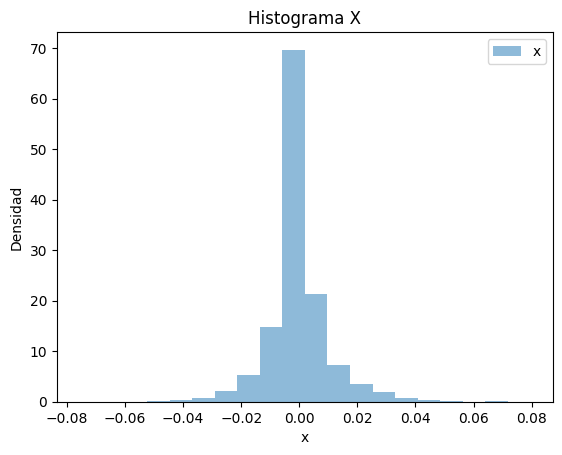

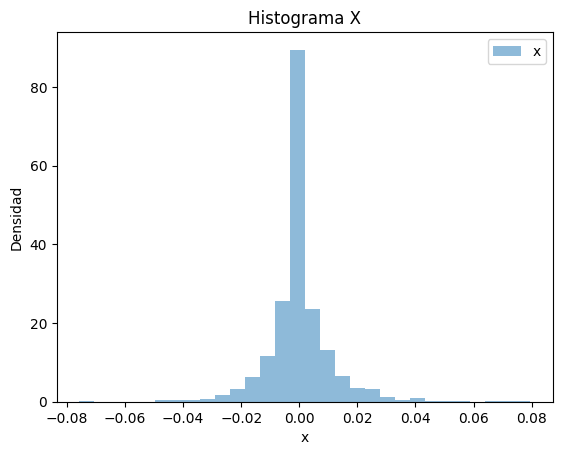

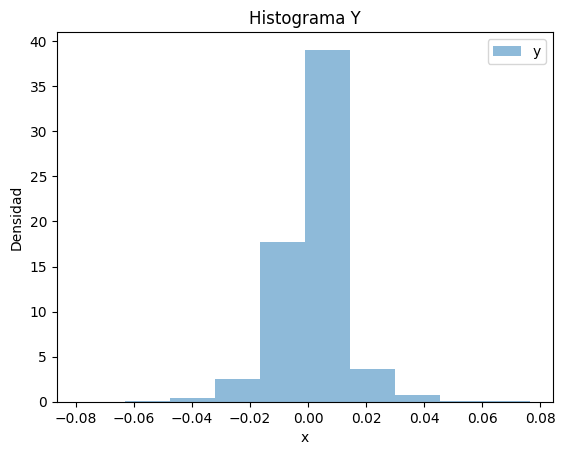

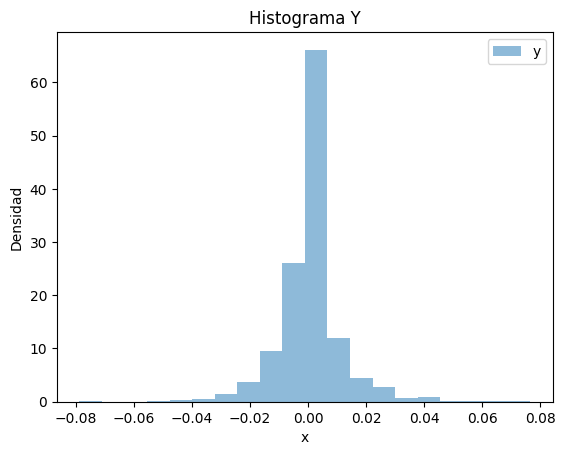

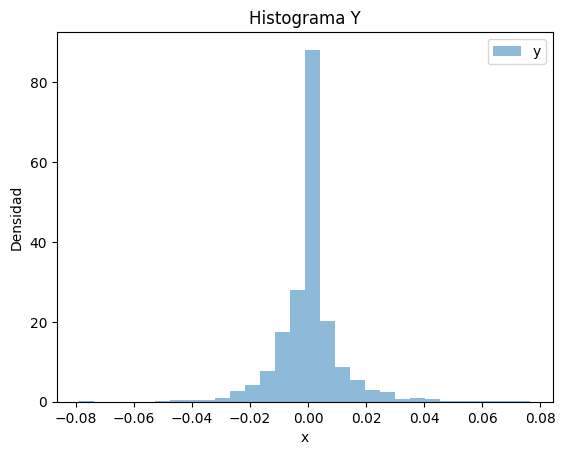

In [ ]:
#problema 3
import matplotlib.pyplot as plt
import numpy as np

# Mostrar los histogramas, este caso x
plt.figure()
plt.hist(datos['relativo'], bins=10, density=True, alpha=0.5, label='x')
plt.xlabel('x')
plt.ylabel('Densidad')
plt.title('Histograma X')
plt.legend()

plt.figure()
plt.hist(datos['relativo'], bins=20, density=True, alpha=0.5, label='x')
plt.xlabel('x')
plt.ylabel('Densidad')
plt.title('Histograma X')
plt.legend()

plt.figure()
plt.hist(datos['relativo'], bins=30, density=True, alpha=0.5, label='x')
plt.xlabel('x')
plt.ylabel('Densidad')
plt.title('Histograma X')
plt.legend()

#histograma de y
plt.figure()
plt.hist(datos['log'], bins=10, density=True, alpha=0.5, label='y')
plt.xlabel('x')
plt.ylabel('Densidad')
plt.title('Histograma Y')
plt.legend()

plt.figure()
plt.hist(datos['log'], bins=20, density=True, alpha=0.5, label='y')
plt.xlabel('x')
plt.ylabel('Densidad')
plt.title('Histograma Y')
plt.legend()

plt.figure()
plt.hist(datos['log'], bins=30, density=True, alpha=0.5, label='y')
plt.xlabel('x')
plt.ylabel('Densidad')
plt.title('Histograma Y')
plt.legend()

#Recordar que al aplicar log a una función, esta tomara la original mas pequeña
#esto sin olvidar que entre mas pequeño x, mas cercano sera el log

In [ ]:
#problema 4
import pandas as pd
import numpy as np
#filtrar los NaN
relativo =datos['relativo'].dropna()

#Estimaciones no parametricas
proba_no_para = {
'P[r > .01]': (relativo > 0.01).mean(),
'0 < r < .01' : ((relativo > 0) & (relativo < 0.01)).mean(),
'0 < r ≤ .01': ((relativo > 0) & (relativo <= 0.01)).mean(),
'0.01< r ≤ .05': ((relativo > 0.01) & (relativo <= 0.05)).mean(),
'0.05 < r ≤ .15' : ((relativo > 0.05) & (relativo <= 0.15)).mean(),
'r ≤0' : (relativo <= 0).mean()
}

#Dada que tengo una normal más arriba, la usare aquí, sin olvidar a:
media_x
std_x

#probas parametricas:
proba_para = {
'r > 0.01': 1 - norm.cdf(0.01, media_x, std_x),
'0 < r < .01': norm.cdf(0.01, media_x, std_x) - norm.cdf(0, media_x, std_x),
'0 < r ≤ .01': norm.cdf(0.01, media_x, std_x) - norm.cdf(0, media_x, std_x),
'.01< r ≤ .05': norm.cdf(0.05, media_x, std_x) - norm.cdf(0.01, media_x, std_x),
'.05 < r ≤ .15': norm.cdf(0.15, media_x, std_x) - norm.cdf(0.05, media_x, std_x),
'r ≤ 0': 1 - norm.cdf(0, media_x, std_x)
}

#Resultados
print("Probabilidades no paramétricas:", proba_no_para)
print("Probabilidades parametricas:", proba_para)

Probabilidades no paramétricas: {'P[r > .01]': 0.10854816824966079, '0 < r < .01': 0.22082767978290366, '0 < r ≤ .01': 0.22082767978290366, '0.01< r ≤ .05': 0.10549525101763908, '0.05 < r ≤ .15': 0.0030529172320217096, 'r ≤0': 0.6706241519674355}
Probabilidades parametricas: {'r > 0.01': 0.18208826070340667, '0 < r < .01': 0.3264588981905111, '0 < r ≤ .01': 0.3264588981905111, '.01< r ≤ .05': 0.18208636848256632, '.05 < r ≤ .15': 1.8922208403493457e-06, 'r ≤ 0': 0.5085471588939178}


In [ ]:
import pandas as pd
import numpy as np

#Exactamente lo mismo pero esta vez para los logaritmos
loga = datos['log'].dropna()

#por facilidad, supondreos que cada una lleva el P[r > 0.01], acá formalon
#no parametricas:
probas_desparametricadas = {
'r > .01': (loga > 0.01).mean(),
'0 < r < .01' : ((loga > 0) & (loga < 0.01)).mean(),
'0 < r ≤ .01': ((loga > 0) & (loga <= 0.01)).mean(),
'0.01< r ≤ .05': ((loga > 0.01) & (loga <= 0.05)).mean(),
'0.05 < r ≤ .15' : ((loga > 0.05) & (loga <= 0.15)).mean(),
'r ≤0' : (loga <= 0).mean()
}


#llamaremos a F
media_y
std_y

#asumire otra vez la normal de arriba
#Probabilidades logaritmicas y paramétricas
probas_para_loga = {
'r ≤ 0': 1 - norm.cdf(0, media_y, std_y),
'0 < r < .001': norm.cdf(0.001, media_y, std_y) - norm.cdf(0, media_y, std_y),
'r > .001': norm.cdf(0.01, media_y, std_y) - norm.cdf(0, media_y, std_y),
'0 < r ≤ .001': norm.cdf(0.05, media_y, std_y) - norm.cdf(0.01, media_y, std_y),
'0.001 < r ≤ .0487': norm.cdf(0.15, media_y, std_y) - norm.cdf(0.05, media_y, std_y),
'0.0489< r ≤ 0.1397': 1 - norm.cdf(0, media_y, std_y)
}

#Presumiremos los resultados
print("Probabilidades no paramétricas:", probas_desparametricadas)
print("Probabilidades parametricas:", probas_para_loga)

Probabilidades no paramétricas: {'r > .01': 0.10820895522388059, '0 < r < .01': 0.22116689280868385, '0 < r ≤ .01': 0.22116689280868385, '0.01< r ≤ .05': 0.10549525101763908, '0.05 < r ≤ .15': 0.0027137042062415195, 'r ≤0': 0.6706241519674355}
Probabilidades parametricas: {'r ≤ 0': 0.5064309362285091, '0 < r < .001': 0.03714790822153241, 'r > .001': 0.32654730106464896, '0 < r ≤ .001': 0.17988192259841718, '0.001 < r ≤ .0487': 1.7125654430127923e-06, '0.0489< r ≤ 0.1397': 0.5064309362285091}


In [ ]:
#tablas que pidio:
import pandas as pd
datos = {
    'Rangos': ['P[X ≤ 0]', 'P[0 < r < .01]', 'P[0 < r ≤ .01]', 'P[0.01< r ≤ .05]'   , 'P[0.05 < r ≤ .15]', 'P[r ≤ 0]' ],
    'No paramétricas': ['0.10854816824966079', '0.22082767978290366', '0.22082767978290366', '0.10549525101763908', '0.0030529172320217096', '0.6706241519674355' ],
    'Paramétrica': [' 0.18208826070340667', '0.3264588981905111', '0.3264588981905111', '0.18208636848256632', '1.8922208403493457e-06', '0.5085471588939178']
        }
dato_loga = {
    'Rangos': [''],
    'No paramétricos': [''],
    'Paramétrica': ['0.1798837003744196', '0.3265472327937273', '0.3265472327937273', '0.17988198779841313', '1.71257600645180' ]
            }

df = pd.DataFrame(datos)
print(df)

              Rangos        No paramétricas             Paramétrica
0           P[X ≤ 0]    0.10854816824966079     0.18208826070340667
1     P[0 < r < .01]    0.22082767978290366      0.3264588981905111
2     P[0 < r ≤ .01]    0.22082767978290366      0.3264588981905111
3   P[0.01< r ≤ .05]    0.10549525101763908     0.18208636848256632
4  P[0.05 < r ≤ .15]  0.0030529172320217096  1.8922208403493457e-06
5           P[r ≤ 0]     0.6706241519674355      0.5085471588939178


In [ ]:
#calculo de intervalos de confianza (problema 5)
#Dado que es una normal, utilizare el caso A, donde es gamma=mu con sigma conocida: Y:=(n)^1/2(media-gamma)/sigma_0

import numpy as np
from statsmodels.stats.proportion import proportion_confint

# Definimos alpha con el nombre de alp_v
alp_v = np.array([0.005, 0.001, 0.0001])

# Hacemos los ciclos de los relativos
for alp in alp_v:
    intervalo_1 = proportion_confint(sum((relativo > 0.005) & (relativo <= 0.01)), len(relativo), alpha=alp, method='wilson')
    print(f"Intervalos de confianza para 0.005 < relativo <= 0.01 con: {alp}")
    print(intervalo_1)

    intervalo_2 = proportion_confint(sum((loga > 0.005) & (loga <= 0.01)), len(loga), alpha=alp, method='wilson')
    print(f"Intervalos de confianza para 0.005 < loga <= 0.01 con: {alp}")
    print(intervalo_2)


Intervalos de confianza para 0.005 < relativo <= 0.01 con: 0.005
(0.06836383718786307, 0.09669006596170399)
Intervalos de confianza para 0.005 < loga <= 0.01 con: 0.005
(0.06867552850449944, 0.09705499222760443)
Intervalos de confianza para 0.005 < relativo <= 0.01 con: 0.001
(0.06632938404026065, 0.09955644580074477)
Intervalos de confianza para 0.005 < loga <= 0.01 con: 0.001
(0.066636236095968, 0.09992553715683564)
Intervalos de confianza para 0.005 < relativo <= 0.01 con: 0.0001
(0.06388750264349395, 0.10321133702639394)
Intervalos de confianza para 0.005 < loga <= 0.01 con: 0.0001
(0.06418832988358344, 0.10358547020796582)


Aqui va la labia, volver para ponerla

In [ ]:
#problema 6
#Para descartar las ultimas 4 semanas, debemos eliminar 20 días (Dado que la bolsa trabaja de lunes a viernes)

import yfinance as yf
import numpy as np
import pandas as pd
from statsmodels.stats.proportion import proportion_confint

# Cargar los datos desde el archivo CSV
datos = yf.download(empresa, start='2010-01-01', end='2024-05-22')
datos.to_csv('datos.csv')
datos = pd.read_csv('datos.csv', index_col='Date', parse_dates=True)

# Excluir los últimos 20 días
datos_filtrados = datos[:-20]

# Definimos alpha con el nombre de alp_v
alp_v = np.array([0.005, 0.001, 0.0001])

relativo
loga
# Hacemos los ciclos de los relativos
for alp in alp_v:
    intervalo_1 = proportion_confint(sum((relativo > 0.005) & (relativo <= 0.01)), len(relativo), alpha=alp, method='wilson')
    print(f"Intervalos de confianza para 0.005 < relativo <= 0.01 con: {alp}")
    print(intervalo_1)

    intervalo_2 = proportion_confint(sum((loga > 0.005) & (loga <= 0.01)), len(loga), alpha=alp, method='wilson')
    print(f"Intervalos de confianza para 0.005 < loga <= 0.01 con: {alp}")
    print(intervalo_2)


[*********************100%%**********************]  1 of 1 completed

Intervalos de confianza para 0.005 < relativo <= 0.01 con: 0.005
(0.06836383718786307, 0.09669006596170399)
Intervalos de confianza para 0.005 < loga <= 0.01 con: 0.005
(0.06867552850449944, 0.09705499222760443)
Intervalos de confianza para 0.005 < relativo <= 0.01 con: 0.001
(0.06632938404026065, 0.09955644580074477)
Intervalos de confianza para 0.005 < loga <= 0.01 con: 0.001
(0.066636236095968, 0.09992553715683564)
Intervalos de confianza para 0.005 < relativo <= 0.01 con: 0.0001
(0.06388750264349395, 0.10321133702639394)
Intervalos de confianza para 0.005 < loga <= 0.01 con: 0.0001
(0.06418832988358344, 0.10358547020796582)


Exactamente igual, volver a completar la explicación

[*********************100%%**********************]  1 of 1 completed


2948
0.0001729815229575726
0.00011514204131521602
Intervalos de confianza para la media (E[Y]):
alpha0.005:
  Lower: -0.00038177301042642623
  Upper: 0.0007277360563415715
alpha0.001:
  Lower: -0.00047732580219919234
  Upper: 0.0008232888481143376
alpha0.0001:
  Lower: -0.0005959167749094044
  Upper: 0.0009418798208245497
Intervalos de confianza para la varianza (V[Y]):
alpha0.005:
  Lower: 0.00010714042275229226
  Upper: 0.00012401817200806962
alpha0.001:
  Lower: 0.00010583387270926309
  Upper: 0.00012563300802177587
alpha0.0001:
  Lower: 0.00010424178701469484
  Upper: 0.0001276762683476938


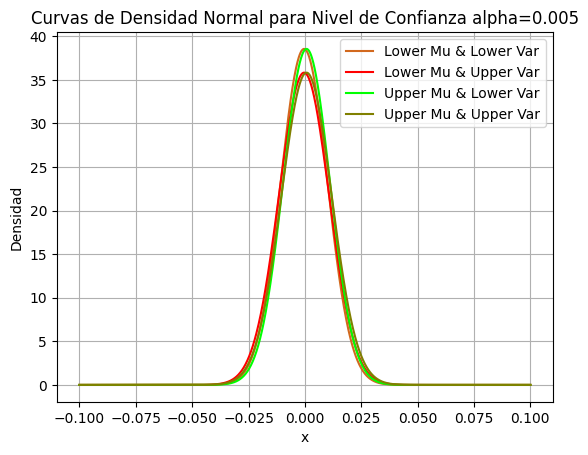

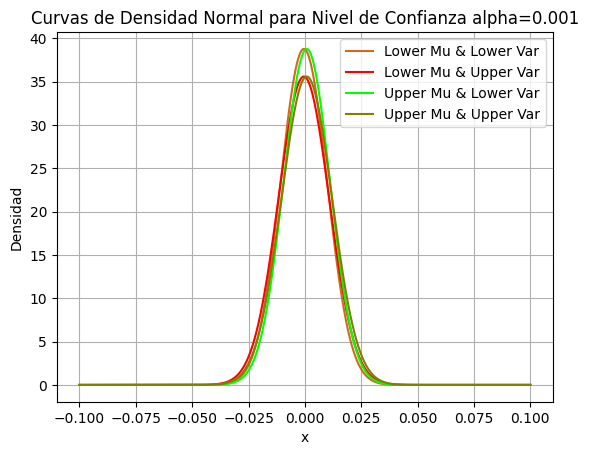

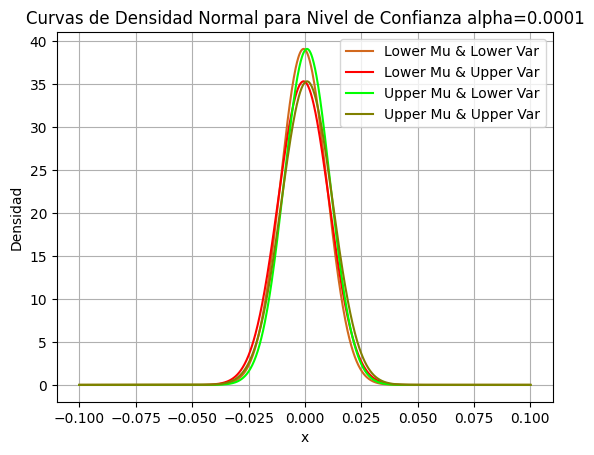

In [ ]:
#Que rápido llegamos al 7 (Después de 9 expresos y cancelarle una cita a la niña bonita de Derecho en las ultimas 24 horaas)
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import scipy.stats as stats
import yfinance as yf

#Cargar datos de la empresa
empresa = 'ACTINVRB.MX'
datos = yf.download(empresa, start='2010-01-01', end='2024-05-22')
datos.to_csv('datos.csv')
datos = pd.read_csv('datos.csv', index_col='Date', parse_dates=True)

# Calcular los rendimientos relativos y logarítmicos

datos['relativo'] = (datos['Adj Close'] - datos['Adj Close'].shift(1)) / datos['Adj Close'].shift(1)
datos['log'] = np.log(datos['Adj Close'] / datos['Adj Close'].shift(1))


rela = datos['relativo'].dropna()
logo = datos['log'].dropna()

# Tamaño de la muestra
n = len(logo)
print(n)

# Media y varianza muestral
mu_log = logo.mean()
sig_log = logo.var()

print(mu_log)
print(sig_log)

# Definir niveles de confianza
ala_v = np.array([0.005, 0.001, 0.0001])

# Inicializar listas para almacenar los intervalos de confianza
mu_arri = {}
mu_aba = {}
var_arri = {}
var_aba = {}

# Calcular el intervalo de confianza para la media (E[Y]) y la varianza (V[Y])
for ala in ala_v:
    z = stats.norm.ppf(1 - ala / 2)

    # Intervalo de confianza para la media
    se_mu = np.sqrt(sig_log / n)
    i_mu = [mu_log - z * se_mu, mu_log + z * se_mu]

    # Intervalo de confianza para la varianza usando Chi-cuadrado
    chi2_lower = stats.chi2.ppf(ala / 2, df = n - 1)
    chi2_upper = stats.chi2.ppf(1 - ala / 2, df = n - 1)
    i_sigma = [(n - 1) * sig_log / chi2_upper, (n - 1) * sig_log / chi2_lower]

    # Almacenar los intervalos en los diccionarios correspondientes
    mu_arri[f"alpha{ala}"] = i_mu[1]
    mu_aba[f"alpha{ala}"] = i_mu[0]
    var_arri[f"alpha{ala}"] = i_sigma[1]
    var_aba[f"alpha{ala}"] = i_sigma[0]

# Mostrar resultados
print("Intervalos de confianza para la media (E[Y]):")
for ala in ala_v:
    ala_label = f"alpha{ala}"
    print(f"{ala_label}:")
    print(f"  Lower: {mu_aba[ala_label]}")
    print(f"  Upper: {mu_arri[ala_label]}")

print("Intervalos de confianza para la varianza (V[Y]):")
for ala in ala_v:
    ala_label = f"alpha{ala}"
    print(f"{ala_label}:")
    print(f"  Lower: {var_aba[ala_label]}")
    print(f"  Upper: {var_arri[ala_label]}")

#Graficamente:

# Función de densidad normal
def densidad_normal(x, mu, sigma):
    return (1 / (np.sqrt(2 * np.pi) * sigma)) * np.exp(-0.5 * ((x - mu) / sigma)**2)
# Generar una secuencia de valores x para la gráfica
x = np.linspace(-0.1, 0.1, 1000)

# Graficar las densidades para diferentes combinaciones de intervalos de confianza
for ala in ala_v:
    ala_label = f"alpha{ala}"

    # Calcular las densidades para cada combinación de mu y sigma
    dens_lower_mu_lower_var = densidad_normal(x, mu_aba[ala_label], np.sqrt(var_aba[ala_label]))
    dens_lower_mu_upper_var = densidad_normal(x, mu_aba[ala_label], np.sqrt(var_arri[ala_label]))
    dens_upper_mu_lower_var = densidad_normal(x, mu_arri[ala_label], np.sqrt(var_aba[ala_label]))
    dens_upper_mu_upper_var = densidad_normal(x, mu_arri[ala_label], np.sqrt(var_arri[ala_label]))

# Crear la gráfica
    plt.figure()
    plt.plot(x, dens_lower_mu_lower_var, label=f'Lower Mu & Lower Var', color='chocolate')
    plt.plot(x, dens_lower_mu_upper_var, label=f'Lower Mu & Upper Var', color='red')
    plt.plot(x, dens_upper_mu_lower_var, label=f'Upper Mu & Lower Var', color='lime')
    plt.plot(x, dens_upper_mu_upper_var, label=f'Upper Mu & Upper Var', color='olive')

    # Configurar la gráfica
    plt.title(f'Curvas de Densidad Normal para Nivel de Confianza alpha={ala}')
    plt.xlabel('x')
    plt.ylabel('Densidad')
    plt.legend()
    plt.grid(True)
    plt.show()


In [ ]:
#problema 8 y después de cancelar de nuevo a la niña bonita de derecho (Ya no hbablamos :c)
import pandas as pd
import numpy as np
import yfinance as yf
from sklearn.model_selection import train_test_split

#Cargar datos de la empresa
empresa = 'ACTINVRB.MX'
datos = yf.download(empresa, start='2010-01-01', end='2024-05-22')
datos.to_csv('datos.csv')
datos = pd.read_csv('datos.csv', index_col='Date', parse_dates=True)

# Traemos los datos
datos = pd.read_csv('datos.csv', index_col='Date', parse_dates=True)

# Calculamos la data
datos['relativo'] = (datos['Adj Close'] - datos['Adj Close'].shift(1)) / datos['Adj Close'].shift(1)

# Eliminamos filas con NaN
datos.dropna(inplace=True)

# Dividimos los datos en dos grupos
grupo1, grupo2 = train_test_split(datos, test_size=0.5, random_state=42)

print("Grupo 1:")
print(grupo1.head())
print("\nGrupo 2:")
print(grupo2.head())



[*********************100%%**********************]  1 of 1 completed

Grupo 1:
             Open   High    Low  Close  Adj Close  Volume  relativo
Date                                                               
2016-08-23  13.02  13.20  13.02  13.19  12.120662   27776 -0.020787
2010-06-17  10.71  10.72  10.71  10.71   9.316849   15000 -0.000933
2012-11-22  11.06  11.06  11.06  11.06   9.799181     520  0.000000
2020-07-30   8.50   8.50   8.50   8.50   7.912558    9932  0.000000
2011-10-26  10.74  10.74  10.50  10.50   9.218410   10200 -0.018692

Grupo 2:
             Open   High    Low  Close  Adj Close  Volume  relativo
Date                                                               
2012-10-31  11.39  11.39  11.39  11.39  10.091560    9300  0.000000
2015-07-23  15.63  15.63  15.62  15.62  14.281891  351300 -0.000640
2023-08-03  14.00  14.00  14.00  14.00  13.598176  205046  0.000000
2017-04-17  12.69  12.69  12.63  12.69  11.721980   15607  0.000000
2019-10-15  11.98  11.98  11.95  11.95  11.124126    3216 -0.003336


In [ ]:
#problema 9
import pandas as pd
import numpy as np
from scipy.stats import norm
import yfinance as yf

# Volvemos a los datos
empresa = 'ACTINVRB.MX'
datos = yf.download(empresa, start='2010-01-01', end='2024-05-22')
datos.to_csv('datos.csv')
datos = pd.read_csv('datos.csv', index_col='Date', parse_dates=True)

pre = datos['Adj Close']
vol = datos['Volume']

correla = pre. corr(vol)
print(correla)



[*********************100%%**********************]  1 of 1 completed

0.010052332564550492
